#A. Cel projektu

Głównym celem niniejszego projektu jest budowa i optymalizacja modeli uczenia maszynowego (przede wszystkim klasyfikatorów opartych na algorytmach drzewiastych), których zadaniem jest przewidywanie prawdopodobieństwa wystąpienia udaru. Predykcja opiera się na analizie szeregu wejściowych cech demograficznych i klinicznych pacjenta, takich jak: wiek, płeć, wskaźnik masy ciała (BMI), historia przebytych chorób (w tym nadciśnienie i choroby serca) oraz status palenia tytoniu. Ze względu na zróżnicowany charakter danych (jakościowe i ilościowe), w projekcie wykorzystano zarówno techniki klasyfikacyjne (do detekcji udaru), jak i regresyjne.

#B. Część teoretyczna

##**Teoria Drzew Decyzyjnych**

Drzewa decyzyjne to wszechstronne algorytmy uczenia nadzorowanego, które modelują decyzje w postaci struktury grafu skierowanego (drzewa). Przestrzeń cech jest sekwencyjnie dzielona na rozłączne regiony za pomocą reguł decyzyjnych (tzw. węzłów).

**Drzewa Klasyfikacyjne**

W przypadku problemu przewidywania udaru (zmienna docelowa kategoryczna: "tak" / "nie"), stosuje się drzewa klasyfikacyjne. Algorytm szuka takiego podziału danych, który maksymalizuje jednorodność (czystość) węzłów potomnych. Miarą tej "nieczystości" jest najczęściej entropia. Zamiast standardowej notacji, entropię zbioru treningowego $\mathcal{Z}$ dla $C$ klas możemy wyrazić wzorem:$$\mathcal{H}(\mathcal{Z}) = - \sum_{j=1}^{C} \pi_j \log_2(\pi_j)$$gdzie $\pi_j$ to frakcja obserwacji należących do klasy $j$ w danym węźle. Algorytm na każdym kroku wybiera tę cechę, która maksymalizuje przyrost informacji, czyli doprowadza do największego spadku wartości funkcji $\mathcal{H}$ po podziale.

**Drzewa Regresyjne**

Do estymacji ciągłych wartości numerycznych (np. wskaźnika BMI) wykorzystuje się wariant regresyjny drzewa. W tym przypadku liście nie zwracają klasy, lecz wartość liczbową – najczęściej jest to średnia arytmetyczna z wartości docelowych próbek, które wpadły do danego liścia. Jako kryterium optymalności podziału nie stosuje się entropii, lecz minimalizację wariancji wewnątrz węzła:$$\mathcal{V}(\Omega) = \frac{1}{N_\Omega} \sum_{k \in \Omega} \left( \upsilon_k - \bar{\upsilon}_\Omega \right)^2$$gdzie $\Omega$ to zbiór obserwacji w węźle, $N_\Omega$ to ich liczba, $\upsilon_k$ to wartość rzeczywista, a $\bar{\upsilon}_\Omega$ to średnia w tym węźle. Zjawisko "schodkowania" predykcji widoczne dla płytkich drzew wynika właśnie z faktu, że model przypisuje jedną, stałą wartość średnią dla całego regionu wyznaczonego przez liść.

##**Problem Niezbalansowania Danych i Oversampling**

W medycznych zbiorach danych dotyczących rzadkich zdarzeń (takich jak udar) występuje drastyczne niezbalansowanie klas. Przykładowo, pacjenci zdrowi stanowią często ponad 95% zbioru, a osoby po udarze zaledwie kilka procent. Standardowy klasyfikator uczony na takich danych ma tendencję do ignorowania klasy mniejszościowej, osiągając wysoką ogólną dokładność poprzez naiwne prognozowanie, że "nikt nie ma udaru". Aby temu zaradzić, w projekcie zastosowano oversampling (nadpróbkowanie).

**Czym jest oversampling?**

Polega on na sztucznym wyrównaniu proporcji klas w zbiorze treningowym poprzez powielanie (losowe losowanie ze zwracaniem) istniejących obserwacji z klasy mniejszościowej lub generowanie nowych, syntetycznych próbek. Dzięki temu model "zwraca większą uwagę" na przypadki udarów podczas nauki i uczy się faktycznych wzorców ich rozpoznawania, co drastycznie poprawia jego czułość, która w medycynie jest parametrem krytycznym (lepiej błędnie ostrzec zdrowego, niż zignorować chorego).

##**Walidacja Modelu i Metryki Błędu**

**Kroswalidacja (Cross-validation)**

Aby zapobiec przeuczeniu (overfitting) i rzetelnie ocenić zdolność modelu do generalizacji wiedzy, zastosowano techniki kroswalidacji (najczęściej k-krotnej, k-fold). Zbiór danych dzielony jest na $K$ podzbiorów. W jednej iteracji $K-1$ podzbiorów służy do uczenia modelu, a jeden do jego testowania. Proces powtarza się $K$ razy, a ostateczny wynik to średnia z wszystkich iteracji. Zapewnia to, że hiperparametry (np. głębokość drzewa) optymalizowane są na twardych danych, a nie dopasowywane do konkretnego, "szczęśliwego" podziału zbioru.

**Błąd Średniokwadratowy (MSE)**

W zadaniach regresyjnych kluczową metryką do oceny odległości przewidywań od rzeczywistości jest MSE (ang. Mean Squared Error). Zdefiniujmy go dla $M$ próbek, gdzie przewidywana wartość to $\hat{\tau}$, a obserwowana to $\tau$:$$\text{MSE} = \frac{1}{M} \sum_{i=1}^{M} \left( \hat{\tau}_i - \tau_i \right)^2$$

##**Algorytmy Zespołowe (Ensemble Methods)**

Pojedyncze drzewa decyzyjne mają skłonność do przeuczenia i dużej wariancji (niewielka zmiana w danych treningowych mocno zmienia strukturę drzewa). Rozwiązaniem tego problemu są modele zespołowe.

**Las Losowy (Random Forest)**

Algorytm ten buduje zespół wielu niezależnych drzew decyzyjnych wykorzystując technikę Baggingu (Bootstrap Aggregating). Każde drzewo uczy się na innej, wylosowanej ze zwracaniem próbce danych treningowych. Dodatkowo, podczas szukania optymalnego podziału w węźle, algorytm nie analizuje wszystkich dostępnych cech pacjenta, a jedynie losowy ich podzbiór (hiperparametr max_features). Decyzja końcowa modelu to "głosowanie większościowe" (w klasyfikacji) lub średnia arytmetyczna z predykcji wszystkich drzew (w regresji). Skutkuje to ogromnym spadkiem wariancji i zwiększeniem odporności na szum.

**Gradient Boosting (GBM)**

W przeciwieństwie do Lasu Losowego, Gradient Boosting uczy drzewa sekwencyjnie. Każde kolejne, małe drzewo (tzw. słaby uczeń) jest dodawane do zespołu w celu naprawienia błędów popełnionych przez wszystkie poprzednie drzewa.

**Co oznacza "Gradient" w tym algorytmie?**

Kluczem jest tu matematyczna optymalizacja. Algorytm minimalizuje dowolną, różniczkowalną funkcję straty $\mathcal{L}$. W każdym kroku $(t)$, model nie próbuje bezpośrednio przewidzieć wartości docelowej $y$, lecz uczy się na kierunku ujemnego gradientu funkcji straty. Przewiduje tak zwane pseudo-reszty (pseudo-residuals), oznaczmy je jako $\rho_i^{(t)}$:$$\rho_{i}^{(t)} = - \left[ \frac{\partial \mathcal{L}(y_i, \hat{y}_i)}{\partial \hat{y}_i} \right]_{\hat{y}_i = \hat{y}_i^{(t-1)}}$$

Mówiąc prościej: gradient to wskaźnik pokazujący, w którym kierunku model popełnił największy błąd. Każde nowe drzewo jest dodawane z określonym współczynnikiem uczenia, co ogranicza drastyczne zmiany i pozwala modelowi powoli i precyzyjnie "zjeżdżać" w kierunku minimum błędu. To właśnie to sekwencyjne schodzenie po gradiencie błędów czyni ten algorytm niezwykle skutecznym i zazwyczaj lepszym od Lasu Losowego, co udowodniono w wynikach kroswalidacji.

#C. Raport

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as skm

from matplotlib.pyplot import subplots
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from imblearn.over_sampling import RandomOverSampler

from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.tree import plot_tree
from sklearn.tree import export_text

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.ensemble import GradientBoostingRegressor as GBR

In [ ]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

data = data[data['gender'] != 'Other']

nr_gr = 5.1
r_k = 2026
np.random.seed(int(nr_gr * r_k))

q = data.shape
idx = np.random.permutation(q[0])

data = data.iloc[idx[0:5000], :]
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
772,72547,Male,61.00,0,0,Yes,Private,Rural,55.26,33.2,Unknown,0
1118,30989,Female,65.00,0,0,Yes,Self-employed,Rural,220.52,37.2,smokes,0
657,20364,Female,4.00,0,0,No,children,Urban,107.25,12.0,Unknown,0
3251,14877,Male,0.56,0,0,No,children,Rural,127.23,20.1,Unknown,0
1094,41861,Female,23.00,0,0,No,Private,Rural,63.73,25.6,smokes,0


**Krok 1: Czyszczenie danych i kodowanie zmiennych kategorycznych**

*Opis kroku: Usunięcie zbędnych identyfikatorów , identyfikacja duplikatów i braków danych oraz konwersja atrybutów nominalnych na wartości liczbowe.*  

In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 772 to 4709
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   age                5000 non-null   float64
 3   hypertension       5000 non-null   int64  
 4   heart_disease      5000 non-null   int64  
 5   ever_married       5000 non-null   object 
 6   work_type          5000 non-null   object 
 7   Residence_type     5000 non-null   object 
 8   avg_glucose_level  5000 non-null   float64
 9   bmi                4804 non-null   float64
 10  smoking_status     5000 non-null   object 
 11  stroke             5000 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 507.8+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4804.000000,5000.000000
mean,36527.996400,43.225400,0.097400,0.054800,106.311940,28.882848,0.049200
std,21143.401919,22.626929,0.296531,0.227612,45.408184,7.864894,0.216307
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17759.500000,25.000000,0.000000,0.000000,77.275000,23.500000,0.000000
50%,36877.000000,45.000000,0.000000,0.000000,91.910000,28.000000,0.000000
75%,54656.000000,61.000000,0.000000,0.000000,114.320000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
# Oczyszczanie danych
data = data.drop('id', axis=1)

# Sprawdzanie duplikatów
duplikaty = data.duplicated().sum()
print("Liczba duplikatów:", duplikaty)

# Weryfikacja braków danych
braki = data.isnull().sum()
print("Brakujące wartości w kolumnach:\n", braki)

# Usuwanie rekordów z brakami
data = data.dropna(axis=0)

Liczba duplikatów: 0
Brakujące wartości w kolumnach:
 gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  196
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
data2 = pd.DataFrame()

data2['age'] = data['age']
data2['avg_glucose_level'] = data['avg_glucose_level']
data2['bmi'] = data['bmi']
data2['hypertension'] = data['hypertension']
data2['heart_disease'] = data['heart_disease']
data2['stroke'] = data['stroke']

data2['gender_Male'] = np.int64(data['gender'] == 'Male')
data2['ever_married'] = np.int64(data['ever_married'] == 'Yes')
data2['Residence_Urban'] = np.int64(data['Residence_type'] == 'Urban')

data2['work_type_Private'] = np.int64(data['work_type'] == 'Private')
data2['work_type_Self_emp'] = np.int64(data['work_type'] == 'Self-employed')
data2['work_type_Govt_job'] = np.int64(data['work_type'] == 'Govt_job')
data2['work_type_children'] = np.int64(data['work_type'] == 'children')
data2['work_type_Never_worked'] = np.int64(data['work_type'] == 'Never_worked')

data2['smoking_formerly'] = np.int64(data['smoking_status'] == 'formerly smoked')
data2['smoking_never'] = np.int64(data['smoking_status'] == 'never smoked')
data2['smoking_smokes'] = np.int64(data['smoking_status'] == 'smokes')
data2['smoking_Unknown'] = np.int64(data['smoking_status'] == 'Unknown')

data2.head()

,age,avg_glucose_level,bmi,hypertension,heart_disease,stroke,gender_Male,ever_married,Residence_Urban,work_type_Private,work_type_Self_emp,work_type_Govt_job,work_type_children,work_type_Never_worked,smoking_formerly,smoking_never,smoking_smokes,smoking_Unknown
772,61.00,55.26,33.2,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1
1118,65.00,220.52,37.2,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0
657,4.00,107.25,12.0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1
3251,0.56,127.23,20.1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1
1094,23.00,63.73,25.6,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0


**Krok 2: Konstrukcja modelu bazowego klasyfikacji (Drzewo Decyzyjne)**

*Opis kroku: Podział zbioru na część treningową i testową , budowa modelu klasyfikatora oraz weryfikacja dokładności za pomocą macierzy pomyłek (Confusion Matrix)*

In [ ]:
X = data2.drop('stroke', axis=1)
y = data2['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

dt = DTC(criterion='entropy', max_depth=5, random_state=1)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

accuracy_score(y_test, y_pred)

0.9614984391259105

Optymalna głębokość drzewa wynosi: 1
Najwyższa dokładność z kroswalidacji wynosi: 95.55%


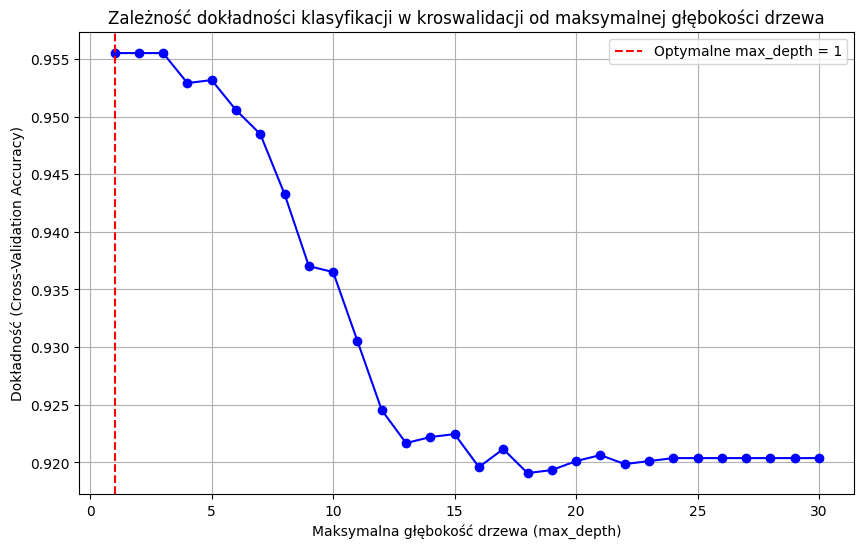

In [ ]:
max_depth_range = range(1, 31)

cv_scores = []
cw_max = 0
md_opt = 0

for depth in max_depth_range:
    dt = DTC(criterion='entropy', max_depth=depth, random_state=1)
    score = cross_val_score(dt, X_train, y_train, cv=10).mean()
    cv_scores.append(score)
    if score > cw_max:
        cw_max = score
        md_opt = depth

print(f"Optymalna głębokość drzewa wynosi: {md_opt}")
print(f"Najwyższa dokładność z kroswalidacji wynosi: {cw_max * 100:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, cv_scores, marker='o', linestyle='-', color='b')
plt.title('Zależność dokładności klasyfikacji w kroswalidacji od maksymalnej głębokości drzewa')
plt.xlabel('Maksymalna głębokość drzewa (max_depth)')
plt.ylabel('Dokładność (Cross-Validation Accuracy)')
plt.grid(True)
plt.axvline(x=md_opt, color='r', linestyle='--', label=f'Optymalne max_depth = {md_opt}')
plt.legend()
plt.show()

Wykres jednoznacznie ukazuje zjawisko silnego przeuczenia modelu wraz ze wzrostem jego złożoności, gdzie najwyższą dokładność na poziomie 95,55% w kroswalidacji osiągnęło najprostsze możliwe drzewo o głębokości zaledwie 1. Każde dalsze zwiększanie głębokości powoduje gwałtowny spadek skuteczności, co dowodzi, że głębszy algorytm jedynie uczy się na pamięć danych treningowych, kompletnie tracąc zdolność do generalizacji. Tak wysoki wynik przy zaledwie jednym podziale silnie sugeruje jednak, że analizowany zbiór jest mocno niezbalansowany, a model naiwnie przewiduje zawsze klasę większościową, czyli brak udaru.

Dokładność dla danych treningowych: 95.55%
Dokładność dla danych testowych: 96.25%


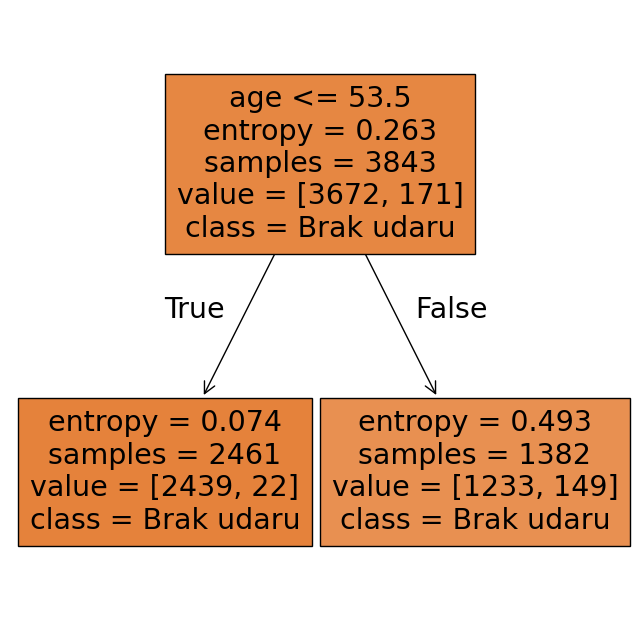

Reguły decyzyjne drzewa:

|--- age <= 53.50
|   |--- weights: [2439.00, 22.00] class: 0
|--- age >  53.50
|   |--- weights: [1233.00, 149.00] class: 0



In [ ]:
dt_opt = DTC(criterion='entropy', max_depth=md_opt, random_state=1)

dt_opt.fit(X_train, y_train)

y_pred_train = dt_opt.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)
print(f"Dokładność dla danych treningowych: {acc_train * 100:.2f}%")

y_pred_test = dt_opt.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"Dokładność dla danych testowych: {acc_test * 100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 8))

plot_tree(dt_opt,
          feature_names=list(X.columns),
          class_names=['Brak udaru', 'Udar'],
          filled=True,
          ax=ax)

plt.show()

regul = export_text(dt_opt,
                    feature_names=list(X.columns),
                    show_weights=True)

print("Reguły decyzyjne drzewa:\n")
print(regul)

Wygenerowane drzewo decyzyjne osiąga pozornie doskonałą dokładność przekraczającą 95% na obu zbiorach, co jest klasyczną pułapką wynikającą z drastycznego niezbalansowania danych. Jedynym kryterium podziału dokonanym przez algorytm jest wiek pacjenta z progiem ustalonym na 53,5 roku, jednak oba utworzone liście końcowe i tak docelowo przypisują wszystkich pacjentów wyłącznie do klasy oznaczającej brak udaru. Oznacza to, że model nauczył się jedynie naiwnego przewidywania klasy większościowej i jest całkowicie bezużyteczny diagnostycznie.

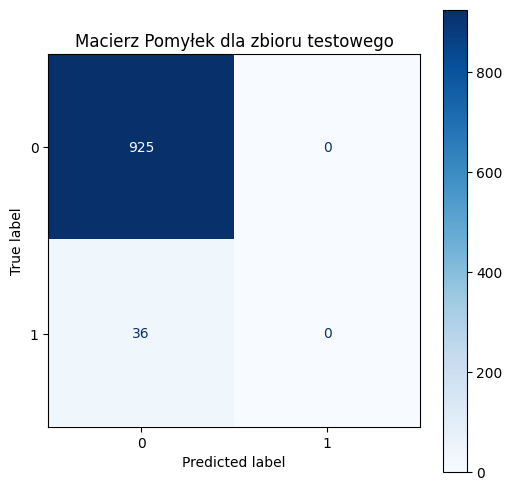

In [ ]:
cm = confusion_matrix(y_test, y_pred_test, labels=dt_opt.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_opt.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')

plt.title('Macierz Pomyłek dla zbioru testowego')
plt.show()

Prawy dolny róg (True Positives = 0): Model nie rozpoznał ani jednego pacjenta chorego na udar. Skuteczność wykrywania choroby jest dosłownie zerowa.

Lewy dolny róg (False Negatives = 36): To jest najgorszy z możliwych błędów w diagnostyce medycznej. W zbiorze testowym było 36 pacjentów z udarem, ale model zignorował ich objawy i sklasyfikował jako zdrowych (fałszywie negatywni).

Lewy górny róg (True Negatives = 925): Model poprawnie wskazał 925 osób zdrowych.

Prawy górny róg (False Positives = 0): Model nie podniósł ani jednego fałszywego alarmu (bo w ogóle nie podnosi alarmów).

**Krok 3: Optymalizacja hiperparametrów i obsługa niezbalansowanych klas**

*Opis kroku: Wykorzystanie kroswalidacji do znalezienia optymalnej głębokości drzewa oraz zastosowanie techniki Oversamplingu (RandomOverSampler) w celu zniwelowania dysproporcji w klasach decyzyjnych.*

Liczebność klas PRZED oversamplingiem:
stroke
0    3672
1     171
Name: count, dtype: int64

Liczebność klas PO oversamplingu:
stroke
0    3672
1    3672
Name: count, dtype: int64

WYNIKI ZADANIA 7 (PO OVERSAMPLINGU)
Optymalna głębokość drzewa (max_depth): 27

WYNIKI ZADANIA 8 (PO OVERSAMPLINGU)
Dokładność (dane treningowe): 100.00%
Dokładność (dane testowe): 93.44%



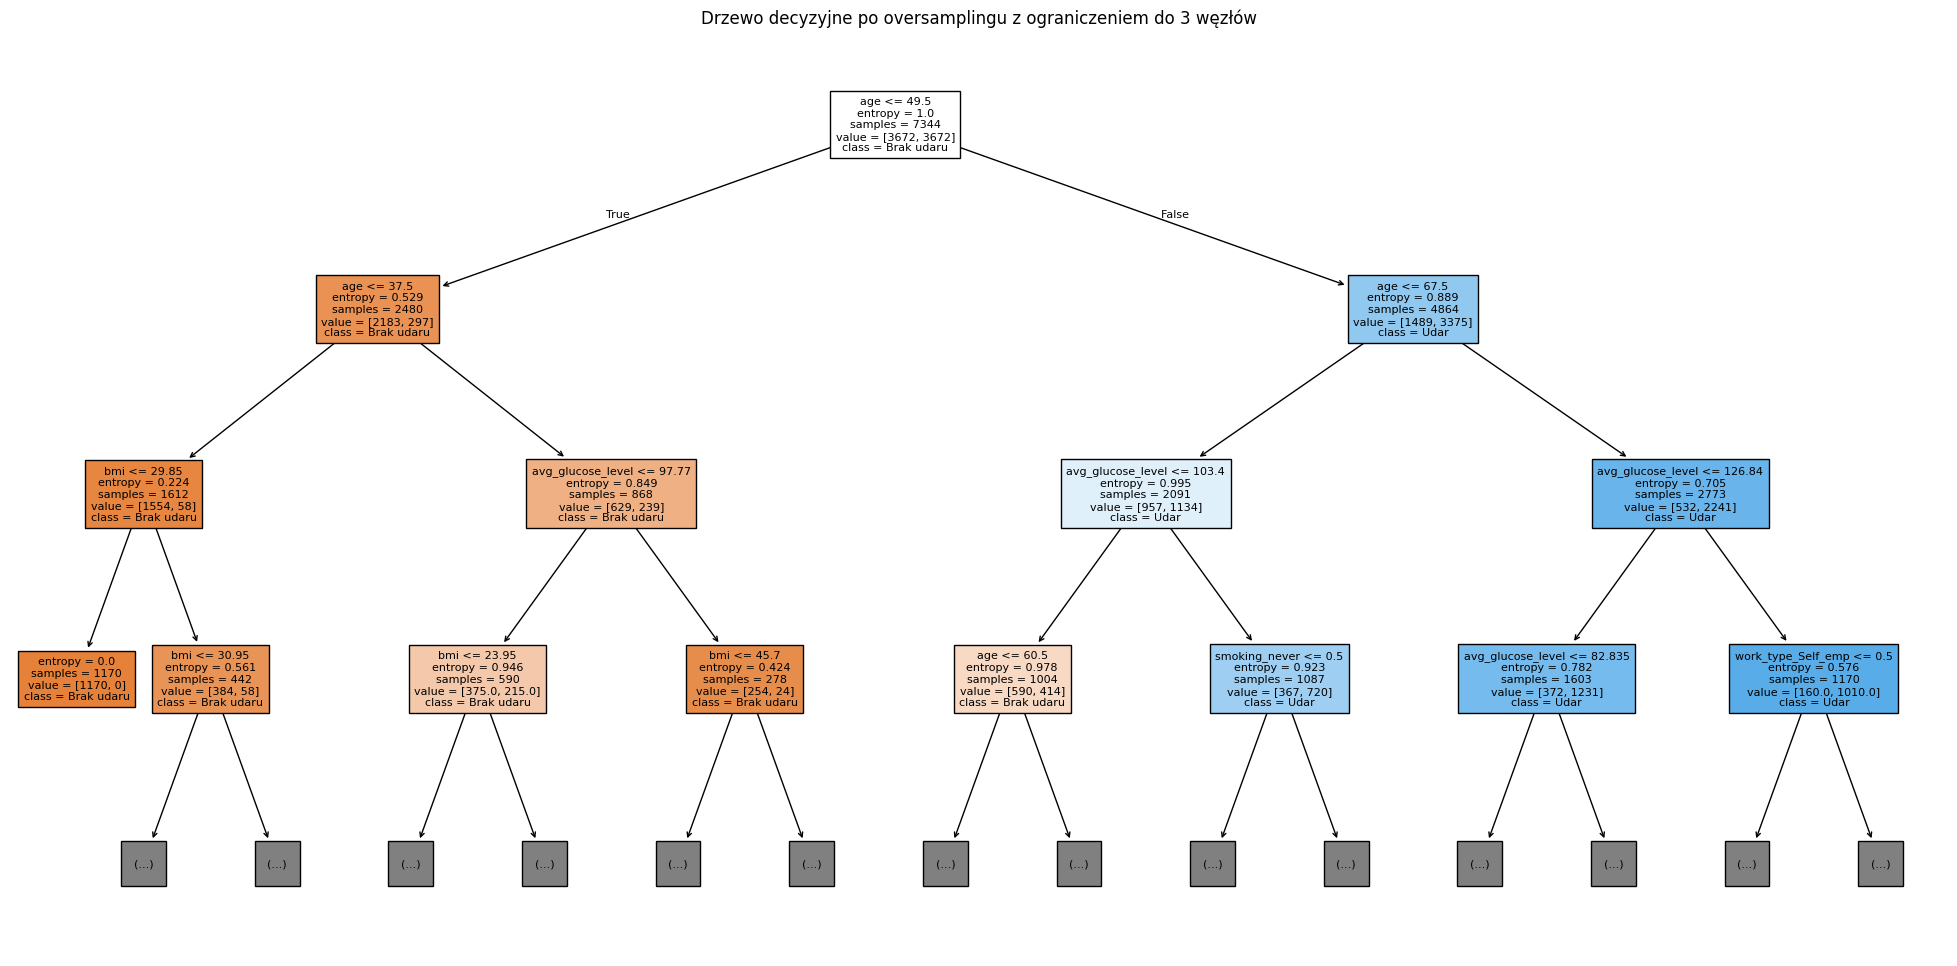

Początkowe węzły drzewa (najważniejsze atrybuty):
 |--- age <= 49.50
|   |--- age <= 37.50
|   |   |--- bmi <= 29.85
|   |   |   |--- class: 0
|   |   |--- bmi >  29.85
|   |   |   |--- bmi <= 30.95
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- bmi >  30.95
|   |   |   |   |--- class: 0
|   |--- age >  37.50
|   |   |--- avg_glucose_level <= 97.77
|   |   |   |--- bmi <= 23.95
|   |   |   |   |--- class: 0
|   |   |   |--- bmi >  23.95
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- avg_glucose_level >  97.77
|   |   |   |--- bmi <= 45.70
|   |   |   |   |--- class: 0
|   |   |   |--- bmi >  45.70
|   |   |   |   |--- truncated branch of depth 2
|--- age >  49.50
|   |--- age <= 67.50
|   |   |--- avg_glucose_level <= 103.40
|   |   |   |--- age <= 60.50
|   |   |   |   |--- truncated branch of depth 15
|   |   |   |--- age >  60.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- avg_glucose_level >  103.40
|   |   |   |--- smoking_never 

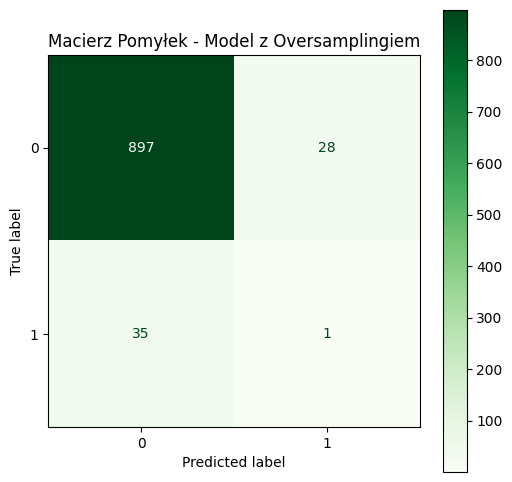

In [ ]:
ros = RandomOverSampler(random_state=1)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print(f"Liczebność klas PRZED oversamplingiem:\n{y_train.value_counts()}\n")
print(f"Liczebność klas PO oversamplingu:\n{y_train_resampled.value_counts()}\n")

max_depth_range = range(1, 31)
cv_scores_res = []
cw_max_res = 0
md_opt_res = 0

for depth in max_depth_range:
    dt = DTC(criterion='entropy', max_depth=depth, random_state=1)
    score = cross_val_score(dt, X_train_resampled, y_train_resampled, cv=10).mean()
    cv_scores_res.append(score)
    if score > cw_max_res:
        cw_max_res = score
        md_opt_res = depth

print("WYNIKI (PO OVERSAMPLINGU)")
print(f"Optymalna głębokość drzewa (max_depth): {md_opt_res}\n")

dt_opt_res = DTC(criterion='entropy', max_depth=md_opt_res, random_state=1)
dt_opt_res.fit(X_train_resampled, y_train_resampled)

y_pred_train_res = dt_opt_res.predict(X_train_resampled)
y_pred_test_res = dt_opt_res.predict(X_test)

print("WYNIKI (PO OVERSAMPLINGU)")
print(f"Dokładność (dane treningowe): {accuracy_score(y_train_resampled, y_pred_train_res) * 100:.2f}%")
print(f"Dokładność (dane testowe): {accuracy_score(y_test, y_pred_test_res) * 100:.2f}%\n")

fig, ax = plt.subplots(figsize=(25,12))
plot_tree(dt_opt_res,
          feature_names=list(X.columns),
          class_names=['Brak udaru', 'Udar'],
          max_depth = 3,
          fontsize = 8,
          filled=True,
          ax=ax)
plt.title('Drzewo decyzyjne po oversamplingu z ograniczeniem do 3 węzłów')
plt.show()

regul_res = export_text(dt_opt_res, feature_names=list(X.columns), max_depth=3)
print("Początkowe węzły drzewa (najważniejsze atrybuty):\n", regul_res)

cm_res = confusion_matrix(y_test, y_pred_test_res, labels=dt_opt_res.classes_)
disp_res = ConfusionMatrixDisplay(confusion_matrix=cm_res, display_labels=dt_opt_res.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp_res.plot(ax=ax, cmap='Greens')
plt.title('Macierz Pomyłek - Model z Oversamplingiem')
plt.show()

Oversampling zbalansował klasy z dysproporcji 3672:171 na równe 3672:3672, eliminując "lenistwo" modelu i wymuszając analizę mniejszościowej klasy udaru.

Optymalna głębokość drzewa skoczyła z 1 do 27 – algorytm zaczął budować złożone reguły oparte na kluczowych cechach: wiek (pierwszy podział), glukoza, BMI, palenie tytoniu i praca, co widać w początkowych węzłach drzewa.

Dokładność na treningu osiągnęła 100% (silne przeuczenie), na teście 93.44% – model zapamiętał zbalansowany zbiór, ale słabo generalizuje.

Macierz pomyłek pokazuje postęp: 1 TP (wykryty udar vs. 0 wcześniej), ale nadal 35 FN (przeoczone udary) i 28 FP (fałszywe alarmy); efekt mieszany – lepsza analiza objawów, lecz overfitting pogarsza praktyczną użyteczność.



**Krok 4: Podejście regresyjne – Predykcja wartości BMI**

*Opis kroku: Wykorzystanie zaawansowanych modeli zespołowych: Random Forest Regressor oraz Gradient Boosting Regressor do estymacji wskaźnika BMI na podstawie pozostałych atrybutów medycznych. Ewaluacja modeli za pomocą błędu średniokwadratowego (MSE).*

Optymalna głębokość drzewa dla przewidywania BMI: 3
Najmniejszy uśredniony błąd MSE w kroswalidacji: 46.71



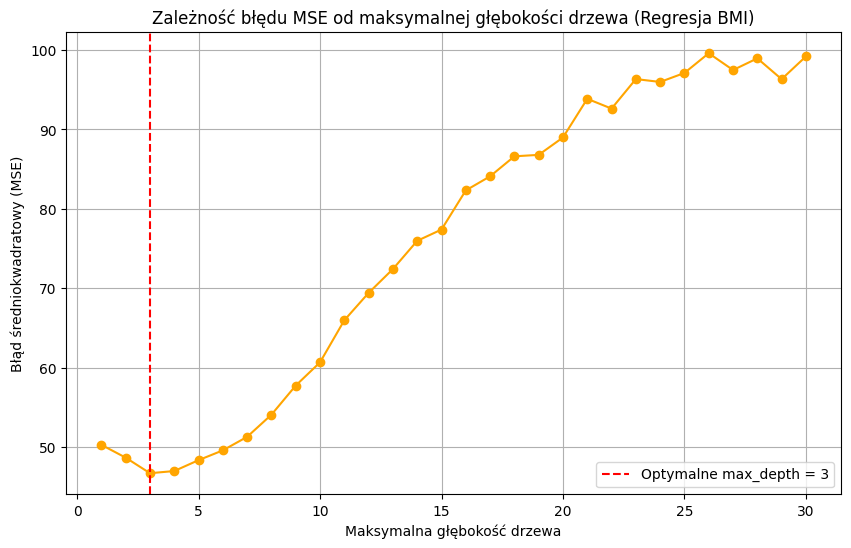

Błąd MSE dla danych treningowych: 46.49
Błąd MSE dla danych testowych: 45.12



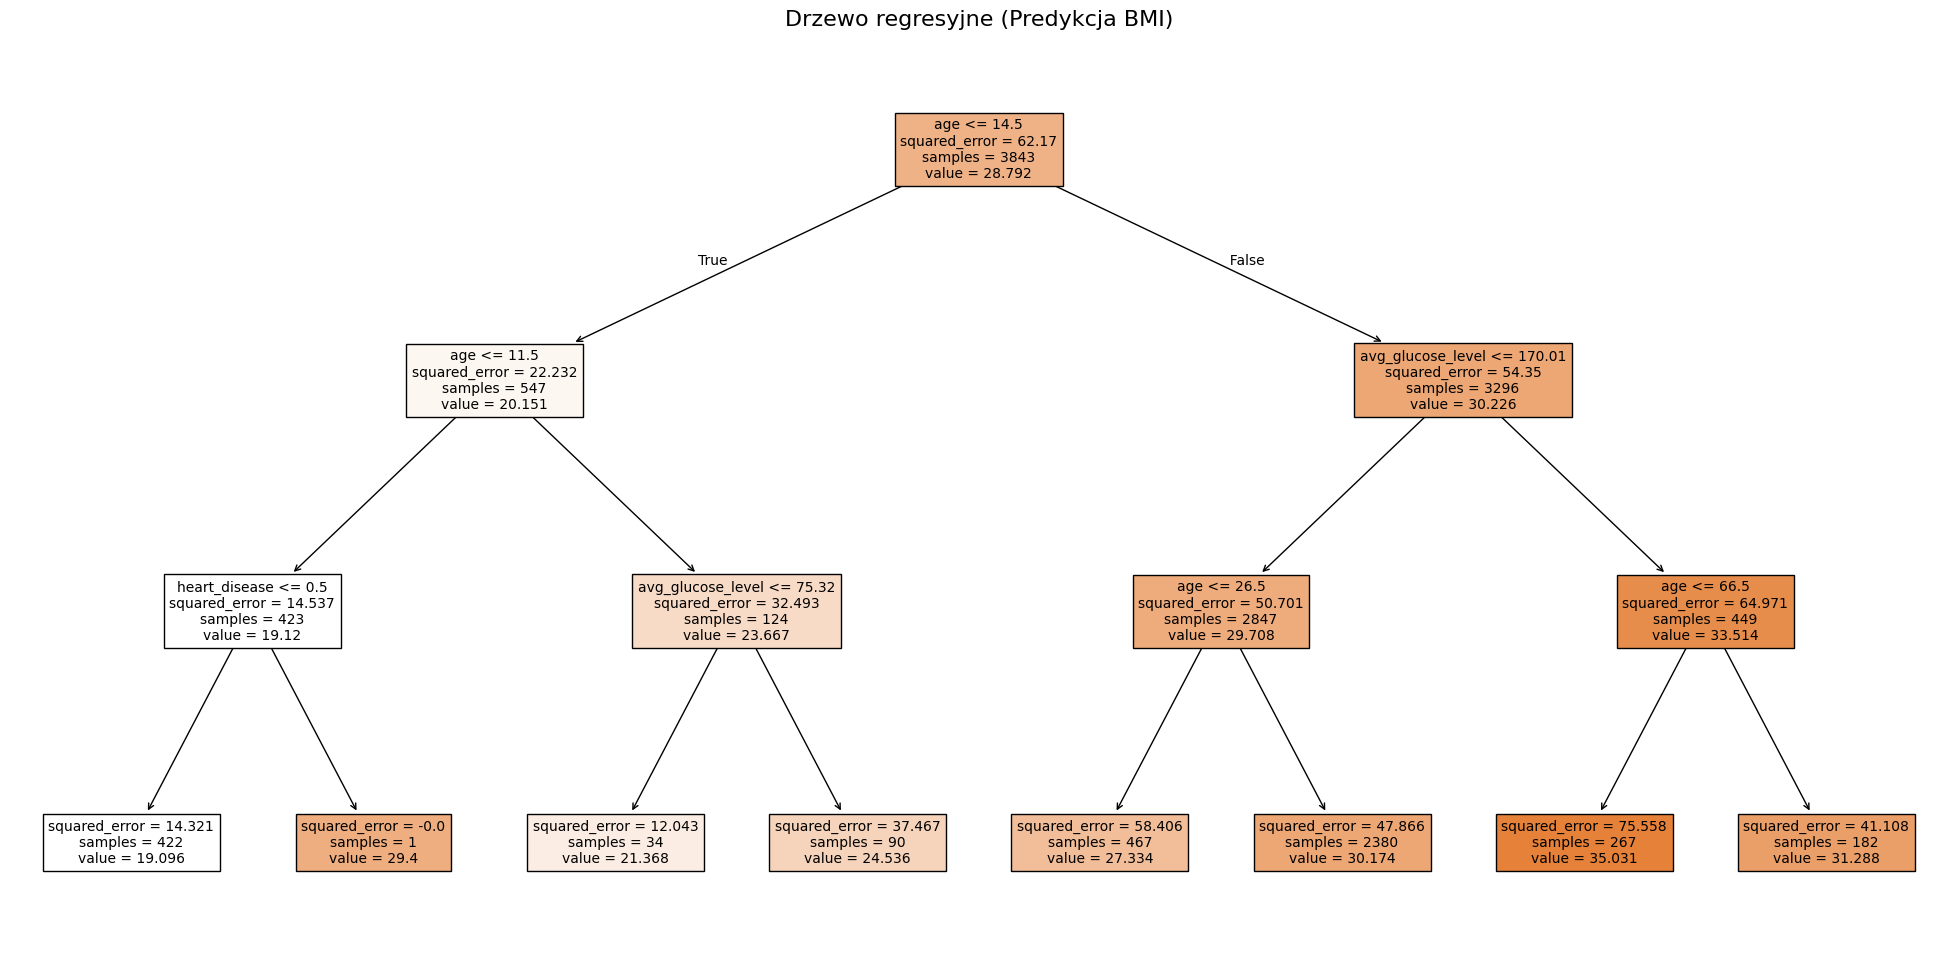

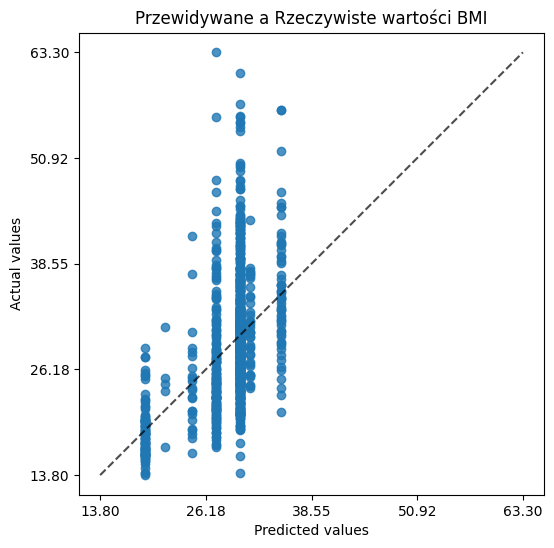

In [ ]:
X2 = data2.drop('bmi', axis=1)
y2 = data2['bmi']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=1)

max_depth_range = range(1, 31)
mse_scores = []
min_mse = float('inf')
md_opt_reg = 0

for depth in max_depth_range:
    dt_reg = DTR(criterion='squared_error', max_depth=depth, random_state=1)
    mse = -cross_val_score(dt_reg, X_train2, y_train2, cv=10, scoring='neg_mean_squared_error').mean()
    mse_scores.append(mse)
    if mse < min_mse:
        min_mse = mse
        md_opt_reg = depth

print(f"Optymalna głębokość drzewa dla przewidywania BMI: {md_opt_reg}")
print(f"Najmniejszy uśredniony błąd MSE w kroswalidacji: {min_mse:.2f}\n")

plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, mse_scores, marker='o', linestyle='-', color='orange')
plt.title('Zależność błędu MSE od maksymalnej głębokości drzewa (Regresja BMI)')
plt.xlabel('Maksymalna głębokość drzewa')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.axvline(x=md_opt_reg, color='r', linestyle='--', label=f'Optymalne max_depth = {md_opt_reg}')
plt.legend()
plt.grid(True)
plt.show()

dt_opt_reg = DTR(criterion='squared_error', max_depth=md_opt_reg, random_state=1)
dt_opt_reg.fit(X_train2, y_train2)

y_pred_train2 = dt_opt_reg.predict(X_train2)
y_pred_test2 = dt_opt_reg.predict(X_test2)

print(f"Błąd MSE dla danych treningowych: {mean_squared_error(y_train2, y_pred_train2):.2f}")
print(f"Błąd MSE dla danych testowych: {mean_squared_error(y_test2, y_pred_test2):.2f}\n")

fig, ax = plt.subplots(figsize=(25, 12))
plot_tree(dt_opt_reg,
          feature_names=list(X2.columns),
          filled=True,
          max_depth=3,
          fontsize=10,
          ax=ax)

plt.title('Drzewo regresyjne (Predykcja BMI)', fontsize=16)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
PredictionErrorDisplay.from_predictions(
    y_true=y_test2,
    y_pred=y_pred_test2,
    kind="actual_vs_predicted",
    ax=ax,
    random_state=1
)
plt.title('Przewidywane a Rzeczywiste wartości BMI')
plt.show()

Wyniki optymalizacji drzewa regresyjnego do przewidywania wartości BMI jednoznacznie wskazują, że najlepszy kompromis pomiędzy złożonością a zdolnością do generalizacji osiągnięto przy płytkiej strukturze o maksymalnej głębokości równej 3. Wykres błędu w kroswalidacji pokazuje, że dalsze rozbudowywanie modelu prowadzi do gwałtownego wzrostu błędu średniokwadratowego (MSE) na nowych danych, co jest klasycznym objawem przeuczenia. Zoptymalizowany algorytm osiąga zbliżone i niskie wartości błędu zarówno dla zbioru treningowego (46,49), jak i testowego (45,12), co ostatecznie potwierdza jego wysoką stabilność oraz całkowity brak overfittingu. Analiza struktury samego drzewa ujawnia, że głównymi atrybutami decydującymi o szacowanej wartości wskaźnika BMI są w pierwszej kolejności wiek pacjenta, a następnie średni poziom glukozy. Z kolei wykres zestawiający predykcje z rzeczywistością doskonale wizualizuje główne ograniczenie tak płytkich modeli, grupując punkty w kilka wyraźnych, pionowych pasm. Zjawisko to wynika bezpośrednio z faktu, że drzewo o głębokości 3 dzieli pacjentów na maksymalnie 8 końcowych liści, przypisując wszystkim osobom w danej grupie jedną, stałą uśrednioną wartość BMI zamiast płynnej estymacji.

Optymalna liczba cech do testu (max_features) wynosi: 11
Najmniejszy uśredniony błąd MSE (kroswalidacja): 46.22



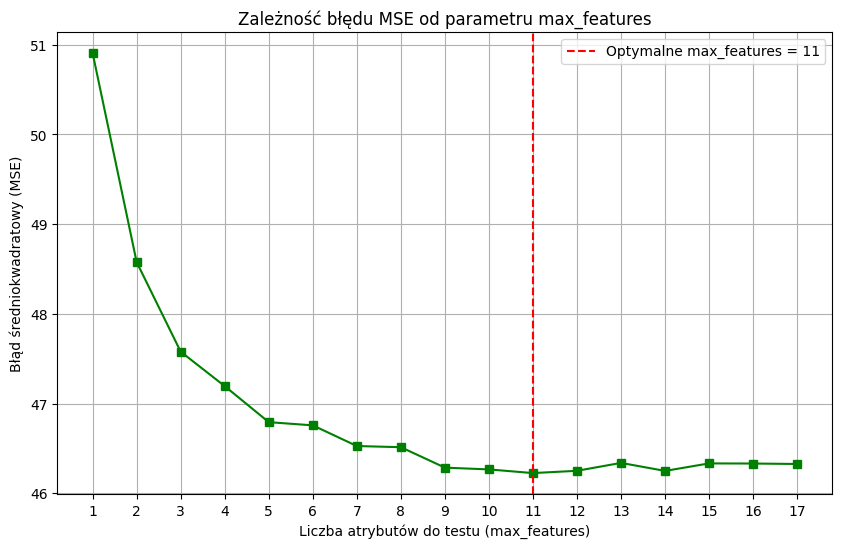

Błąd MSE dla danych testowych (Random Forest): 44.41


In [ ]:
p = X_train2.shape[1]
max_features_range = range(1, p + 1)

mse_scores_rf = []
min_mse_rf = float('inf')
mf_opt = 1

for m in max_features_range:
    rf = RF(max_depth=md_opt_reg, max_features=m, random_state=1)
    mse = -cross_val_score(rf, X_train2, y_train2, cv=10, scoring='neg_mean_squared_error').mean()
    mse_scores_rf.append(mse)
    if mse < min_mse_rf:
        min_mse_rf = mse
        mf_opt = m

print(f"Optymalna liczba cech do testu (max_features) wynosi: {mf_opt}")
print(f"Najmniejszy uśredniony błąd MSE (kroswalidacja): {min_mse_rf:.2f}\n")

plt.figure(figsize=(10, 6))
plt.plot(max_features_range, mse_scores_rf, marker='s', linestyle='-', color='green')
plt.title('Zależność błędu MSE od parametru max_features')
plt.xlabel('Liczba atrybutów do testu (max_features)')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.axvline(x=mf_opt, color='r', linestyle='--', label=f'Optymalne max_features = {mf_opt}')
plt.xticks(max_features_range)
plt.legend()
plt.grid(True)
plt.show()

rf_opt = RF(max_depth=md_opt_reg, max_features=mf_opt, random_state=1)
rf_opt.fit(X_train2, y_train2)

y_pred_test_rf = rf_opt.predict(X_test2)

mse_test_rf = mean_squared_error(y_test2, y_pred_test_rf)
print(f"Błąd MSE dla danych testowych (Random Forest): {mse_test_rf:.2f}")

Przejście od pojedynczego drzewa regresyjnego do modelu zespołowego w postaci Lasu Losowego przyniosło mierzalną poprawę wyników. Wykres optymalizacji hiperparametru określającego maksymalną liczbę cech rozpatrywanych przy podziale węzłów ukazuje, że przy losowaniu zbyt małej puli atrybutów pojedyncze drzewa składowe są zbyt słabe, co skutkuje początkowo wysokim błędem. Wraz ze zwiększaniem liczby dostępnych cech błąd gwałtownie spada i ulega wypłaszczeniu, osiągając swoje absolutne minimum w kroswalidacji na poziomie 46,22 dla dokładnie 11 atrybutów. Najważniejszym potwierdzeniem poprawności zastosowanej metody jest jednak wynik uzyskany na niezależnym zbiorze testowym, gdzie błąd średniokwadratowy spadł do poziomu 44,41. Osiągnięcie błędu testowego niższego od walidacyjnego jest jednoznacznym dowodem na doskonałą zdolność modelu do generalizacji i całkowity brak przeuczenia.

Optymalny współczynnik uczenia (learning_rate): 0.0400
Najmniejszy uśredniony błąd MSE (kroswalidacja): 44.95



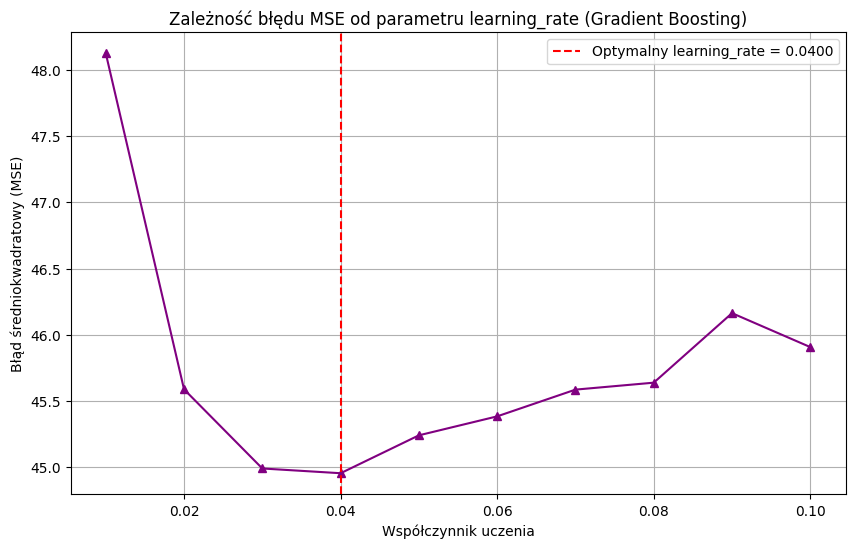

Błąd MSE dla danych testowych (Gradient Boosting): 43.54

ZESTAWIENIE BŁĘDÓW MSE DLA ZBIORU TESTOWEGO
Zadanie 11 (Pojedyncze Drzewo Regresyjne): 45.12
Zadanie 12 (Las Losowy): 44.41
Zadanie 13 (Gradient Boosting): 43.54


In [ ]:
lr_range = np.linspace(0.01, 0.1, 10)

mse_scores_gbr = []
min_mse_gbr = float('inf')
lr_opt = 0.01

for lr in lr_range:
    gbr = GBR(max_depth=md_opt_reg, learning_rate=lr, random_state=1)
    mse = -cross_val_score(gbr, X_train2, y_train2, cv=10, scoring='neg_mean_squared_error').mean()
    mse_scores_gbr.append(mse)
    if mse < min_mse_gbr:
        min_mse_gbr = mse
        lr_opt = lr

print(f"Optymalny współczynnik uczenia (learning_rate): {lr_opt:.4f}")
print(f"Najmniejszy uśredniony błąd MSE (kroswalidacja): {min_mse_gbr:.2f}\n")

plt.figure(figsize=(10, 6))
plt.plot(lr_range, mse_scores_gbr, marker='^', linestyle='-', color='purple')
plt.title('Zależność błędu MSE od parametru learning_rate (Gradient Boosting)')
plt.xlabel('Współczynnik uczenia')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.axvline(x=lr_opt, color='r', linestyle='--', label=f'Optymalny learning_rate = {lr_opt:.4f}')
plt.legend()
plt.grid(True)
plt.show()

gbr_opt = GBR(max_depth=md_opt_reg, learning_rate=lr_opt, random_state=1)
gbr_opt.fit(X_train2, y_train2)

y_pred_test_gbr = gbr_opt.predict(X_test2)
mse_test_gbr = mean_squared_error(y_test2, y_pred_test_gbr)
print(f"Błąd MSE dla danych testowych (Gradient Boosting): {mse_test_gbr:.2f}\n")

print("ZESTAWIENIE BŁĘDÓW MSE DLA ZBIORU TESTOWEGO")
mse_test_dt = mean_squared_error(y_test2, dt_opt_reg.predict(X_test2))

print(f"(Pojedyncze Drzewo Regresyjne): {mse_test_dt:.2f}")
print(f"(Las Losowy): {mse_test_rf:.2f}")
print(f"(Gradient Boosting): {mse_test_gbr:.2f}")

Wyniki optymalizacji algorytmu Gradient Boosting wskazują, że kluczowym czynnikiem dla jego skuteczności jest dobór odpowiedniego współczynnika uczenia, którego optymalna wartość po sprawdzeniu przestrzeni hiperparametrów wyniosła 0,04. Wykres obrazuje klasyczny kompromis, w którym zbyt małe kroki uczenia uniemożliwiają modelowi dotarcie do minimum błędu, a zbyt duże prowadzą do jego ponownego, niestabilnego wzrostu. Utworzony model wykazuje doskonałą zdolność do generalizacji wiedzy, co potwierdza błąd średniokwadratowy na niezależnym zbiorze testowym wynoszący zaledwie 43,54, będący wartością wyraźnie niższą niż minimalny wynik z samej kroswalidacji (44,95). Ostateczne zestawienie wszystkich wytrenowanych w projekcie estymatorów ukazuje wyraźną hierarchię skuteczności metod uczenia maszynowego, w której najprostsze pojedyncze drzewo regresyjne wypadło najsłabiej z błędem rzędu 45,12. Zastosowanie równoległego zespołu drzew w postaci Lasu Losowego przyniosło mierzalną poprawę do poziomu 44,41, jednak zwycięzcą całego zestawienia okazał się algorytm Gradient Boosting, udowadniając w praktyce, że sekwencyjne uczenie płytkich estymatorów skupionych na precyzyjnej redukcji błędów swoich poprzedników pozwala na uzyskanie najdokładniejszego modelu do predykcji wskaźnika BMI.

#D. Wnioski Końcowe

**Złudność ogólnej dokładności w niezbalansowanych danych medycznych**

Najbardziej krytycznym wnioskiem płynącym z części klasyfikacyjnej projektu jest udowodnienie, jak niebezpieczne w diagnostyce medycznej jest poleganie wyłącznie na metryce ogólnej dokładności (accuracy). Projekt dobitnie pokazał, że w obliczu drastycznie niezbalansowanego zbioru danych – gdzie przypadki udaru stanowią rzadkość – standardowy klasyfikator ulega "lenistwu". Osiąga on pozornie perfekcyjne wyniki, ucząc się jedynie naiwnego przewidywania klasy większościowej, co w praktyce oznacza całkowite ignorowanie pacjentów chorych.

**Konieczność i skutki uboczne sztucznego balansowania danych**

Próba rozwiązania problemu mniejszościowej klasy udarów poprzez zastosowanie technik nadpróbkowania (oversampling) okazała się krokiem koniecznym, aby algorytm w ogóle rozpoczął poszukiwanie rzeczywistych wzorców klinicznych. Eksperyment ten obnażył jednak drugą stronę medalu – zrównanie proporcji klas sprawiło, że pojedyncze drzewo decyzyjne gwałtownie zwiększyło swoją złożoność. Model zamiast uogólniać reguły, zaczął dogłębnie uczyć się danych treningowych na pamięć. Doprowadziło to do zjawiska przeuczenia (overfittingu), co w warunkach testowych skutkowało generowaniem wielu fałszywych alarmów i ostatecznie słabą zdolnością do poprawnego diagnozowania nowych pacjentów.

**Strukturalne ograniczenia płytkich drzew w regresji**

W części poświęconej estymacji zmiennej ciągłej (wskaźnika BMI) uwidoczniła się wyraźna wada pojedynczych, płytkich drzew decyzyjnych. Optymalizacja takiego modelu w celu uniknięcia przeuczenia wymusza mocne ograniczenie jego głębokości. W efekcie algorytm traci zdolność do płynnej predykcji, a zamiast tego tworzy sztywne szufladki. Grupuje on pacjentów o różnej specyfice do zaledwie kilku szerokich kategorii, przypisując im identyczną, uśrednioną wartość.

**Wyższość algorytmów zespołowych nad pojedynczymi estymatorami**

Rozwiązaniem na wspomniane ograniczenia okazało się przejście do metod zespołowych (Ensemble Learning). Zbudowanie Lasu Losowego udowodniło, że agregacja wyników z setek różnorodnych, prosto zbudowanych drzew pozwala skutecznie wygładzić predykcje i znacząco zredukować wariancję całego systemu, dając o wiele bezpieczniejszy i dokładniejszy wynik estymacji.

**Rezultaty uczenia sekwencyjnego**

Z całego zestawienia badawczego najlepszym okazał się algorytm Gradient Boosting. Zwycięstwo tej metody w zadaniu predykcji BMI udowadnia wyższość podejścia opartego na ciągłym samodoskonaleniu. W przeciwieństwie do tworzonych niezależnie od siebie drzew w Lesie Losowym, sekwencyjne dokładanie kolejnych, małych estymatorów, z których każdy skupia się wyłącznie na naprawieniu błędów swoich poprzedników, doprowadziło do stworzenia najbardziej precyzyjnego i wysoce odpornego na przeuczenie modelu w całym projekcie.

#E. Literatura

1. Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.

2. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning: Data Mining, Inference, and Prediction. Springer Science & Business Media.